##Loading and inspecting the dataset

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/IDRA/Day18_19_student_habits_performance.csv")
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
df.shape

(1000, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

##Handling missing values and duplicates

In [5]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


Since there are null values in parental_education_level column and it is not clear if it affects the training, the null values will be filled with the mode of the column.

In [6]:
df['parental_education_level'].unique()

array(['Master', 'High School', 'Bachelor', nan], dtype=object)

In [7]:
df['parental_education_level'] = df['parental_education_level'].fillna(df['parental_education_level'].mode()[0])

In [8]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


In [9]:
df['parental_education_level'].unique()

array(['Master', 'High School', 'Bachelor'], dtype=object)

In [10]:
df.duplicated().sum()

np.int64(0)

- The missing values are handled using mode of the respective categorical column (parental_education_level)
- No duplicates, so no need to handle it

##Separating different column types

In [11]:
for col in df.columns:
  print("\n", col, "\n", df[col].unique())


 student_id 
 ['S1000' 'S1001' 'S1002' 'S1003' 'S1004' 'S1005' 'S1006' 'S1007' 'S1008'
 'S1009' 'S1010' 'S1011' 'S1012' 'S1013' 'S1014' 'S1015' 'S1016' 'S1017'
 'S1018' 'S1019' 'S1020' 'S1021' 'S1022' 'S1023' 'S1024' 'S1025' 'S1026'
 'S1027' 'S1028' 'S1029' 'S1030' 'S1031' 'S1032' 'S1033' 'S1034' 'S1035'
 'S1036' 'S1037' 'S1038' 'S1039' 'S1040' 'S1041' 'S1042' 'S1043' 'S1044'
 'S1045' 'S1046' 'S1047' 'S1048' 'S1049' 'S1050' 'S1051' 'S1052' 'S1053'
 'S1054' 'S1055' 'S1056' 'S1057' 'S1058' 'S1059' 'S1060' 'S1061' 'S1062'
 'S1063' 'S1064' 'S1065' 'S1066' 'S1067' 'S1068' 'S1069' 'S1070' 'S1071'
 'S1072' 'S1073' 'S1074' 'S1075' 'S1076' 'S1077' 'S1078' 'S1079' 'S1080'
 'S1081' 'S1082' 'S1083' 'S1084' 'S1085' 'S1086' 'S1087' 'S1088' 'S1089'
 'S1090' 'S1091' 'S1092' 'S1093' 'S1094' 'S1095' 'S1096' 'S1097' 'S1098'
 'S1099' 'S1100' 'S1101' 'S1102' 'S1103' 'S1104' 'S1105' 'S1106' 'S1107'
 'S1108' 'S1109' 'S1110' 'S1111' 'S1112' 'S1113' 'S1114' 'S1115' 'S1116'
 'S1117' 'S1118' 'S1119' 'S1120' 'S1

In [12]:
num_col = ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']

cat_col = ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']

The student_id is the identifier, so it doesn't belong to either the categorical or numerical columns. The rest of the columns are separated into numerical and categorical columns.

##Descriptive statistics

In [13]:
df[num_col].describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


- The average exam score is 69.60, with a standard deviation of 16.89, showing considerable variation in student performance.
- Average study time is 3.55 hours/day.
- Average attendance is 84.13%.
- Average sleep is 6.47 hours/day.
- Average social media usage is 2.51 hours/day, while Netflix usage is 1.82 hours/day.
- Average mental health rating is 5.44/10.
- Exam scores range from 18.4 to 100, indicating a wide range of academic performance.

In [60]:
df[cat_col].describe()

,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
count,1000,1000,1000,1000,1000,1000
unique,3,2,3,3,3,2
top,Female,No,Fair,High School,Good,No
freq,481,785,437,483,447,682


The most frequent categories are:
- Gender → Female
- Part-time job → No
- Diet quality → Fair
- Parental education → High School
- Internet quality → Good
- Extracurricular participation → No

##Distribution and Outliers

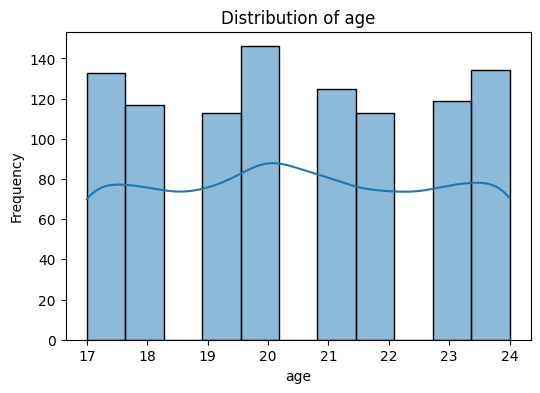

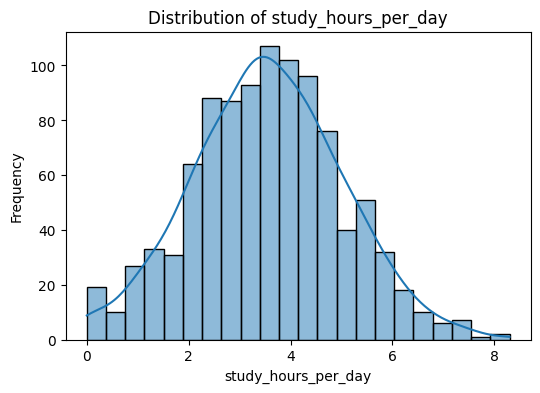

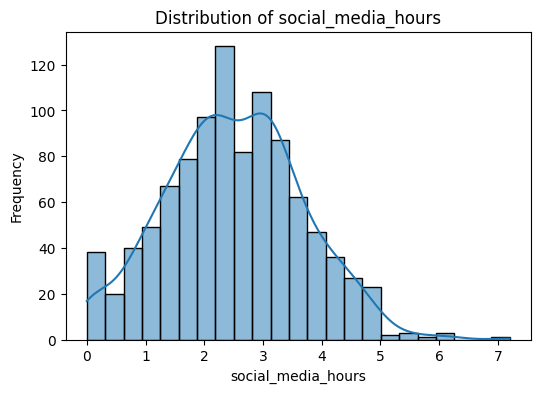

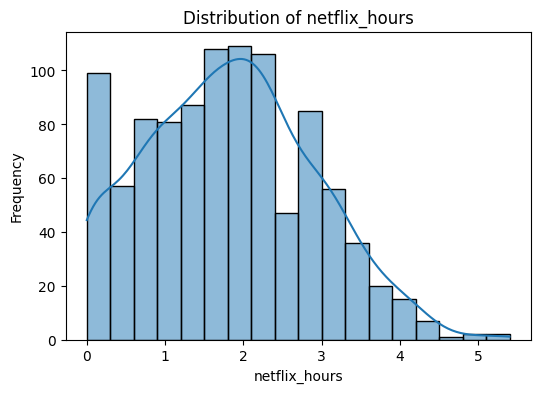

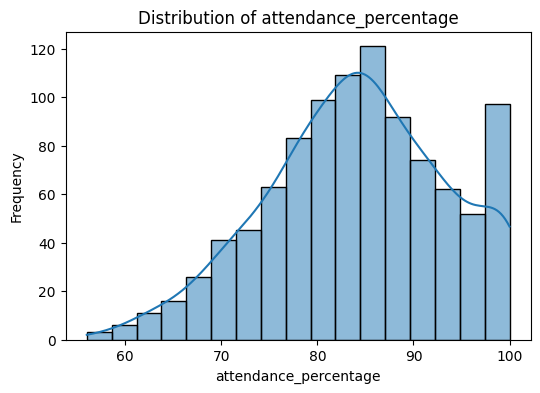

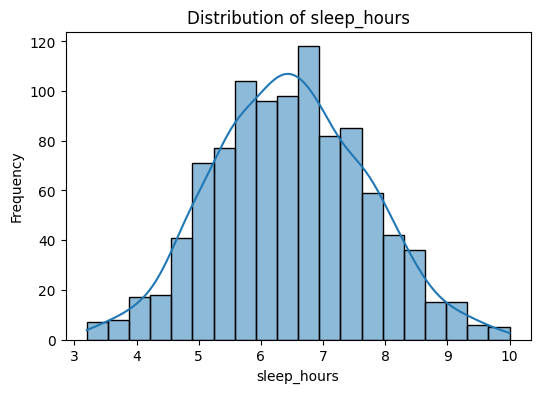

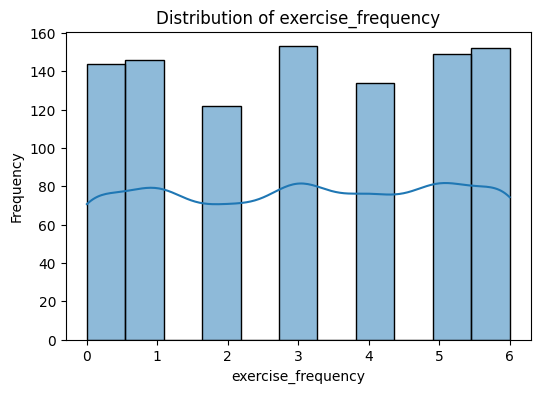

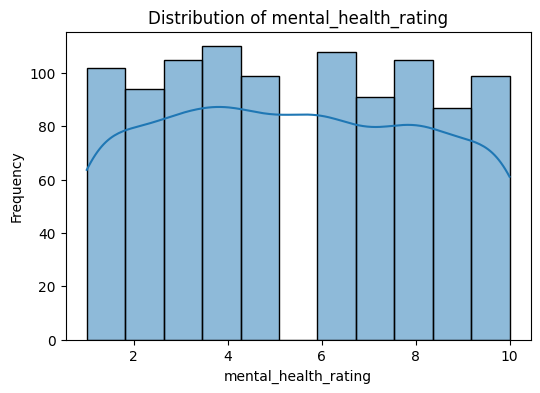

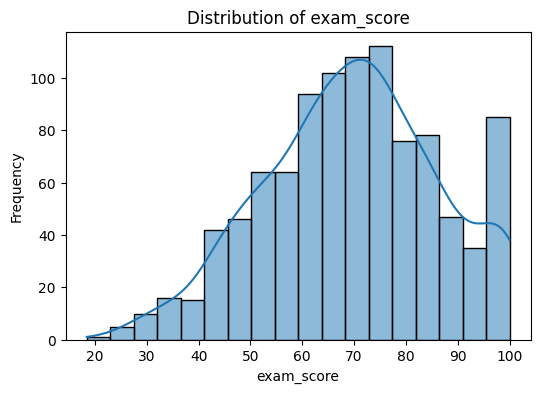

In [16]:
for col in num_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

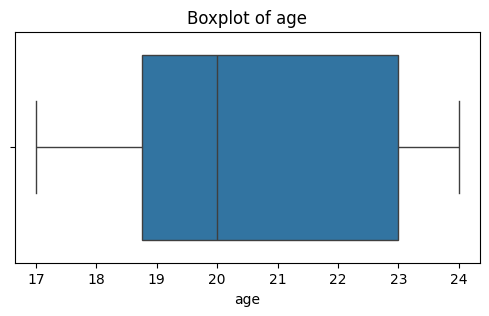

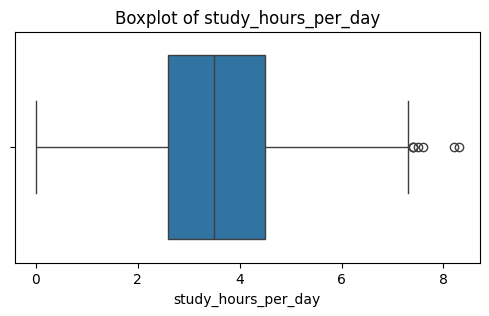

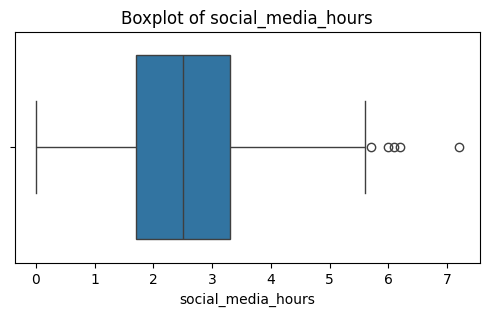

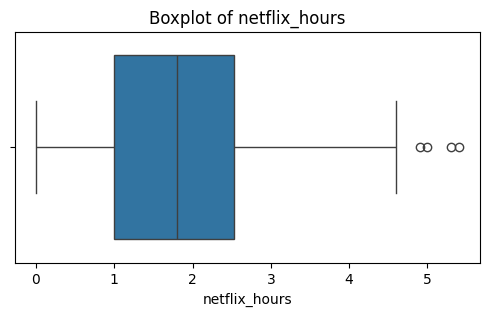

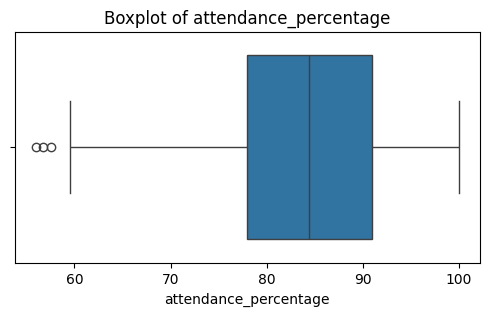

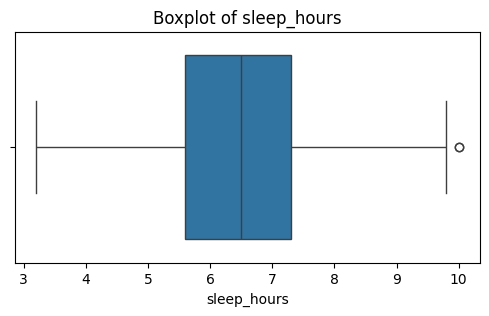

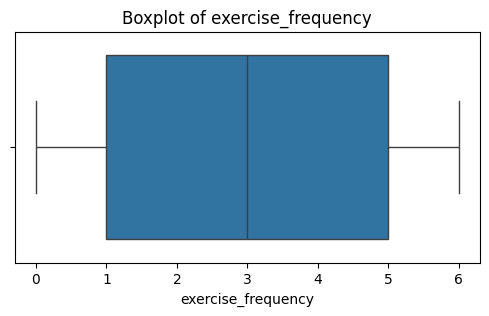

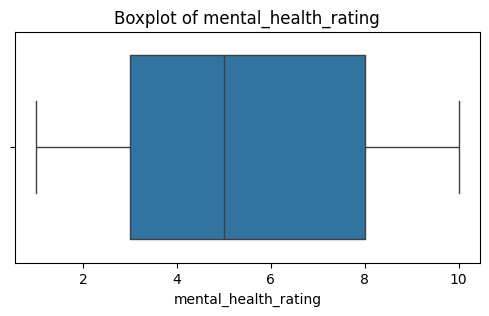

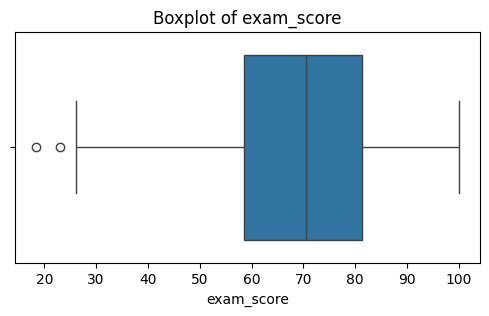

In [17]:
for col in num_col:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [18]:
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, ":", len(outliers), "outliers")

age : 0 outliers
study_hours_per_day : 7 outliers
social_media_hours : 5 outliers
netflix_hours : 4 outliers
attendance_percentage : 3 outliers
sleep_hours : 2 outliers
exercise_frequency : 0 outliers
mental_health_rating : 0 outliers
exam_score : 2 outliers


Most variables have a few or no outliers. Doesn't necessarily need to remove them.

##Relationship with exam_score

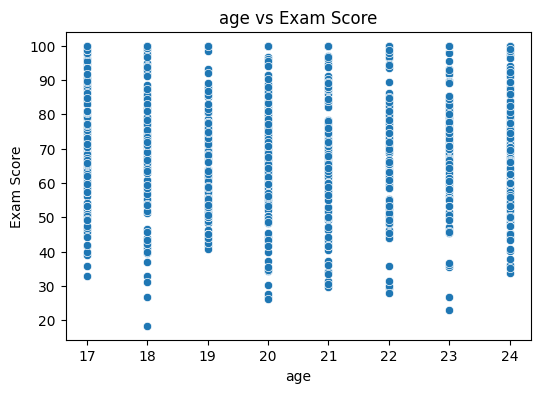

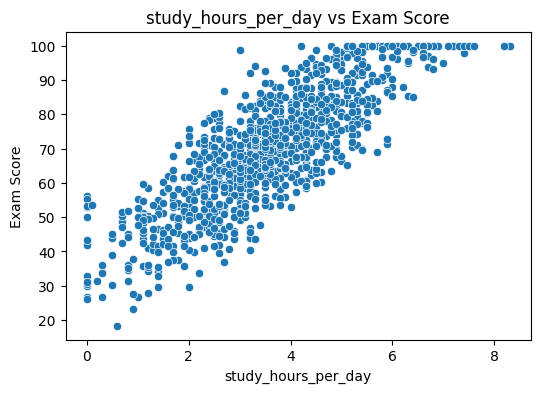

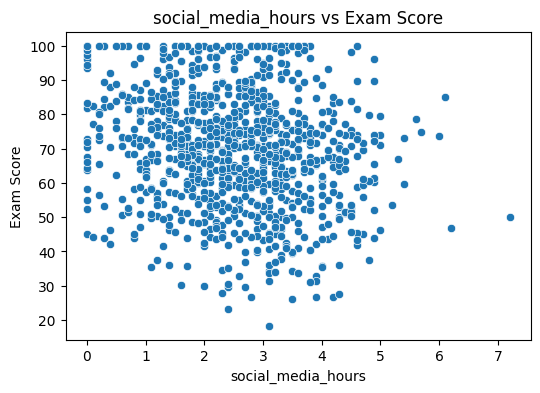

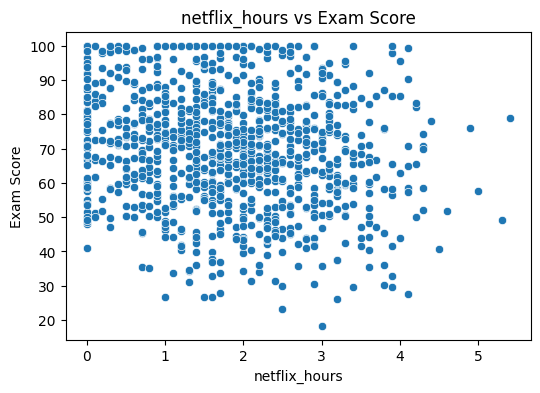

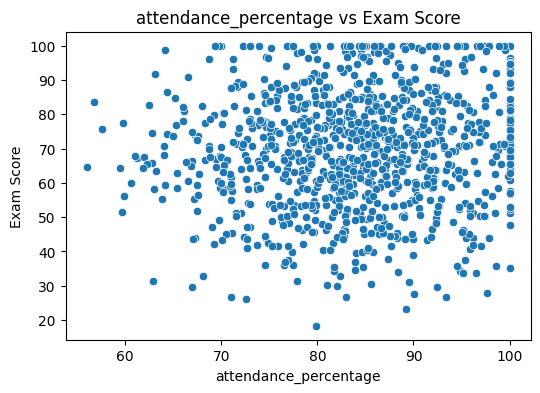

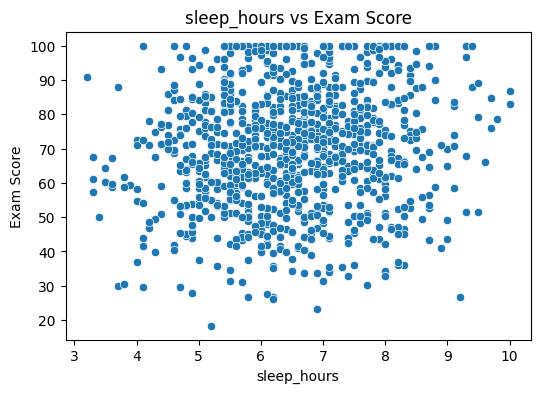

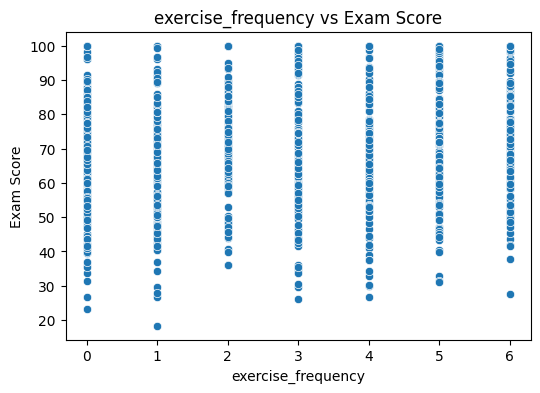

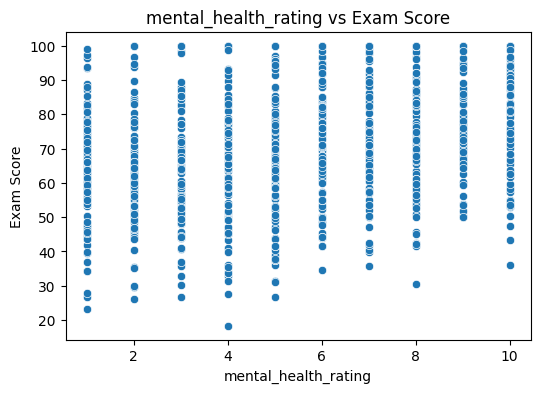

In [19]:
relationship_col = [
    'age',
    'study_hours_per_day',
    'social_media_hours',
    'netflix_hours',
    'attendance_percentage',
    'sleep_hours',
    'exercise_frequency',
    'mental_health_rating'
]

for col in relationship_col:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df['exam_score'])
    plt.title(f'{col} vs Exam Score')
    plt.xlabel(col)
    plt.ylabel('Exam Score')
    plt.show()

- Strongest relationship is study_hours_per_day vs exam_score
- mental health rating has another positive relationship with exam_score
- Age have no relationship with exam score
- the other relationships have only a weak relationship

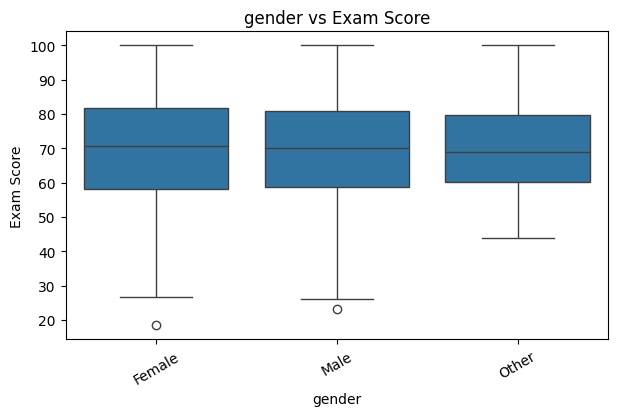

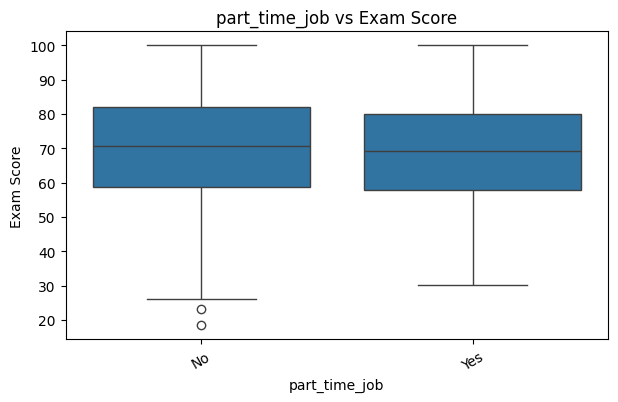

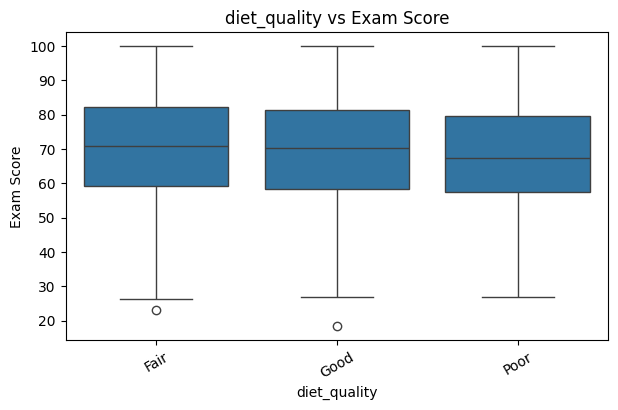

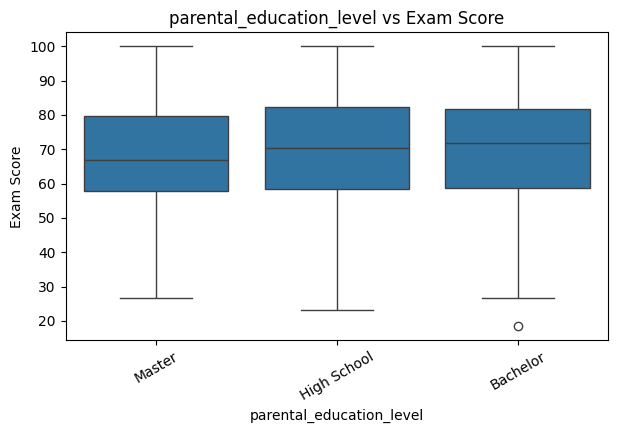

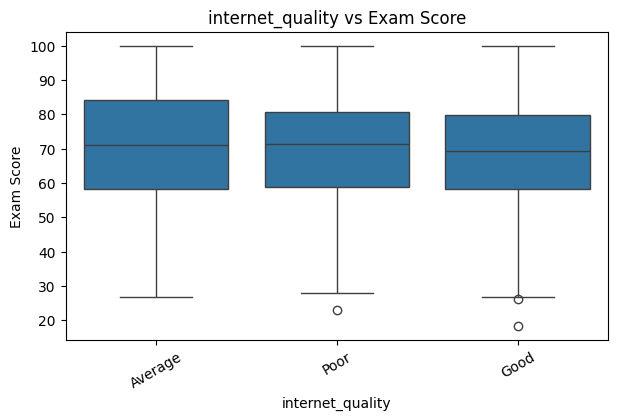

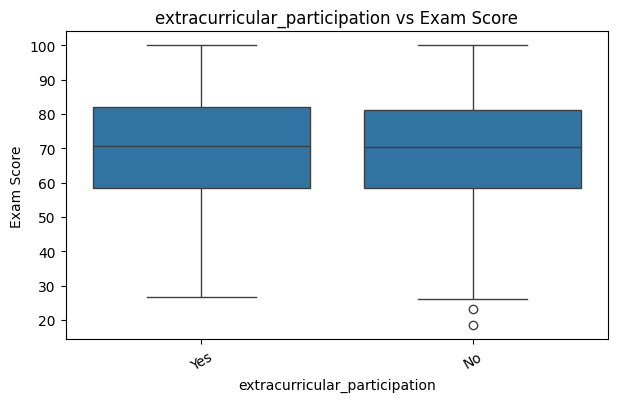

In [20]:
for col in cat_col:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df[col], y=df['exam_score'])
    plt.title(f'{col} vs Exam Score')
    plt.xlabel(col)
    plt.ylabel('Exam Score')
    plt.xticks(rotation=30)
    plt.show()

##Correlation Analysis

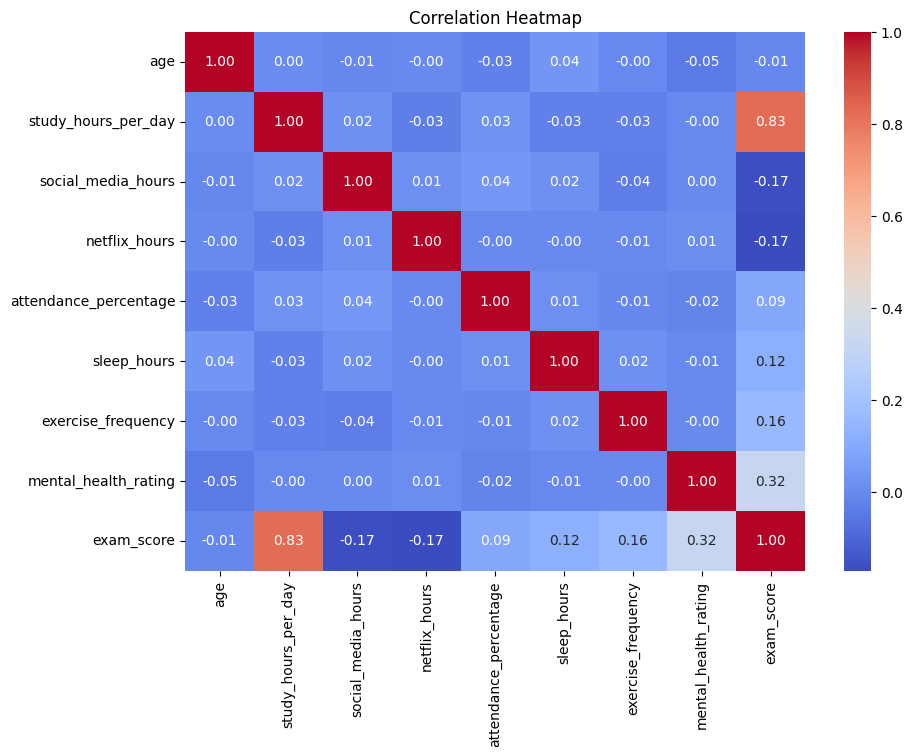

In [21]:
corr = df[num_col].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [22]:
exam_corr = df[num_col].corr()['exam_score'].sort_values(ascending=False)

print(exam_corr)

exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64


- Correlation score between study hours and exam score is 0.83, which indicates a strong positive correlation
- exam score has negative correlation with social media and netflix hours (-0.17)

##Regression Model

In [23]:
X = df.drop(['student_id', 'exam_score'], axis=1)
y = df['exam_score']

In [24]:
X = pd.get_dummies(X, drop_first=True)

In [25]:
X.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,gender_Male,gender_Other,part_time_job_Yes,diet_quality_Good,diet_quality_Poor,parental_education_level_High School,parental_education_level_Master,internet_quality_Good,internet_quality_Poor,extracurricular_participation_Yes
0,23,0.0,1.2,1.1,85.0,8.0,6,8,False,False,False,False,False,False,True,False,False,True
1,20,6.9,2.8,2.3,97.3,4.6,6,8,False,False,False,True,False,True,False,False,False,False
2,21,1.4,3.1,1.3,94.8,8.0,1,1,True,False,False,False,True,True,False,False,True,False
3,23,1.0,3.9,1.0,71.0,9.2,4,1,False,False,False,False,True,False,True,True,False,True
4,19,5.0,4.4,0.5,90.9,4.9,3,1,False,False,False,False,False,False,True,True,False,False


In [26]:
X.shape

(1000, 18)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 18)
Testing data: (200, 18)


In [30]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [31]:
y_train_pred = model.predict(X_train)

In [32]:
y_test_pred = model.predict(X_test)

In [36]:
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 4.192343110379916
MSE : 26.532535044099433
RMSE: 5.150974183986892
R²  : 0.8965307156715967


In [39]:
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

In [61]:
regression_results = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Training': [train_mae, train_mse, train_rmse, train_r2],
    'Testing': [test_mae, test_mse, test_rmse, test_r2]
})

regression_results

,Metric,Training,Testing
0,MAE,4.214166,4.192343
1,MSE,28.566058,26.532535
2,RMSE,5.344722,5.150974
3,R²,0.902108,0.896531


- The model's predictions are off by approximately 4.19 marks on average.
- Typical prediction error is around 5.15 marks, with larger errors receiving more penalty.
- The model explains approximately 89.7% of the variation in exam scores on the testing data.

There is no significant evidence of overfitting, since the training and testing performances are very similar.

##Classification Model

In [40]:
df['Pass_Fail'] = np.where(
    df['exam_score'] >= 50,
    'Pass',
    'Fail'
)

In [42]:
print(df['Pass_Fail'].value_counts(normalize=True) * 100)

Pass_Fail
Pass    86.9
Fail    13.1
Name: proportion, dtype: float64


In [43]:
X_class = df.drop(
    ['student_id', 'exam_score', 'Pass_Fail'],
    axis=1
)

y_class = df['Pass_Fail']

In [46]:
X_class = pd.get_dummies(X_class, drop_first=True)
X_class.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,gender_Male,gender_Other,part_time_job_Yes,diet_quality_Good,diet_quality_Poor,parental_education_level_High School,parental_education_level_Master,internet_quality_Good,internet_quality_Poor,extracurricular_participation_Yes
0,23,0.0,1.2,1.1,85.0,8.0,6,8,False,False,False,False,False,False,True,False,False,True
1,20,6.9,2.8,2.3,97.3,4.6,6,8,False,False,False,True,False,True,False,False,False,False
2,21,1.4,3.1,1.3,94.8,8.0,1,1,True,False,False,False,True,True,False,False,True,False
3,23,1.0,3.9,1.0,71.0,9.2,4,1,False,False,False,False,True,False,True,True,False,True
4,19,5.0,4.4,0.5,90.9,4.9,3,1,False,False,False,False,False,False,True,True,False,False


In [47]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

In [50]:
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train_class, y_train_class)

LogisticRegression(max_iter=1000)

In [52]:
y_train_class_pred = classifier.predict(X_train_class)
y_test_class_pred = classifier.predict(X_test_class)

classification_prediction = pd.DataFrame({
    'Actual': y_test_class,
    'Predicted': y_test_class_pred
})

classification_prediction.head(10)

,Actual,Predicted
541,Pass,Pass
95,Pass,Fail
846,Pass,Pass
260,Pass,Pass
909,Pass,Pass
583,Pass,Pass
275,Pass,Pass
634,Pass,Pass
849,Pass,Pass
931,Pass,Pass


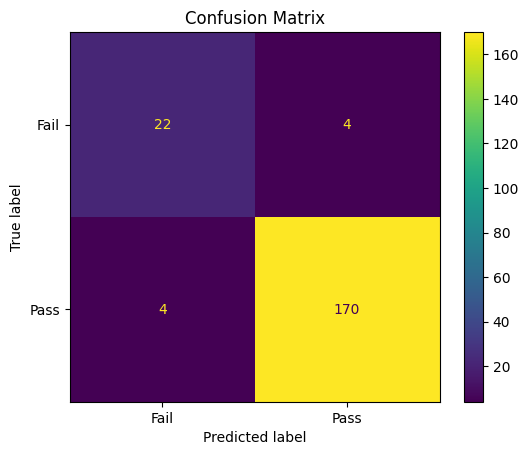

In [55]:
cm = confusion_matrix(
    y_test_class,
    y_test_class_pred,
    labels=['Fail', 'Pass']
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Fail', 'Pass']
)

disp.plot()
plt.title('Confusion Matrix')
plt.show()

True Negatives = 22

False Positives = 4

False Negatives = 4

True Positives = 170

In [56]:
accuracy = accuracy_score(y_test_class, y_test_class_pred)

precision = precision_score(
    y_test_class,
    y_test_class_pred,
    pos_label='Pass'
)

recall = recall_score(
    y_test_class,
    y_test_class_pred,
    pos_label='Pass'
)

f1 = f1_score(
    y_test_class,
    y_test_class_pred,
    pos_label='Pass'
)

print(f"Accuracy: {accuracy}\nPrecision: {precision}\nRecall: {recall}\nF1 score = {f1}")

Accuracy: 0.96
Precision: 0.9770114942528736
Recall: 0.9770114942528736
F1 score = 0.9770114942528736


In [57]:
train_accuracy = accuracy_score(y_train_class, y_train_class_pred)
train_precision = precision_score(
    y_train_class,
    y_train_class_pred,
    pos_label='Pass'
)
train_recall = recall_score(
    y_train_class,
    y_train_class_pred,
    pos_label='Pass'
)
train_f1 = f1_score(
    y_train_class,
    y_train_class_pred,
    pos_label='Pass'
)

test_accuracy = accuracy_score(y_test_class, y_test_class_pred)
test_precision = precision_score(
    y_test_class,
    y_test_class_pred,
    pos_label='Pass'
)
test_recall = recall_score(
    y_test_class,
    y_test_class_pred,
    pos_label='Pass'
)
test_f1 = f1_score(
    y_test_class,
    y_test_class_pred,
    pos_label='Pass'
)

In [59]:
classification_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Training': [
        train_accuracy,
        train_precision,
        train_recall,
        train_f1
    ],
    'Testing': [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1
    ]
})

classification_results

,Metric,Training,Testing
0,Accuracy,0.955000,0.960000
1,Precision,0.971388,0.977011
2,Recall,0.976978,0.977011
3,F1-score,0.974175,0.977011


- The model correctly classified 96% of the testing students as Pass or Fail.
- Among students predicted as Pass, approximately 97.7% actually passed.
- The model correctly identified approximately 97.7% of the students who actually passed.
- The high F1-score indicates a good balance between precision and recall.

##Overfitting / Underfitting
The classification model achieved high and consistent performance on both training and testing data. Since the training and testing metrics are very close, there is no significant evidence of overfitting or underfitting. The model generalizes well to unseen data.

#Insights
- Study hours have the strongest positive correlation with exam score (0.825).
- Mental health shows a moderate positive relationship (0.322).
- Social media and Netflix usage show weak negative relationships (-0.167, -0.172).
- Linear Regression achieved R² = 0.897 and MAE = 4.19.
- Logistic Regression achieved 96% accuracy and 97.70% F1-score, showing good generalization.